# Deep Learning for Drug Response Prediction with Gene Expression Data

## Overview
This project aims to build deep learning models that predict how gene expression changes in human immune cells when treated with different drugs. The dataset is derived from single-cell perturbation experiments where peripheral blood mononuclear cells (PBMCs) from human donors were treated with various compounds, and the resulting gene expression changes were measured using single-cell RNA sequencing.

## Problem Statement
Given a drug and a specific immune cell type, the goal is to predict the differential expression values of thousands of genes after drug treatment. These values represent how strongly a gene is upregulated or downregulated compared to a control condition.

## Input Features
The model uses the following inputs:
- **cell_type**: Type of immune cell (T cells, B cells, NK cells, Myeloid cells)
- **sm_name**: Drug / small molecule name
- **sm_lincs_id**: Unique identifier for the compound
- **SMILES**: Chemical structure representation of the compound

## Output
The model predicts differential expression values for **18,211 genes**, represented as signed −log10(p-values) indicating both the direction and strength of gene regulation.

## Modeling Approach
The project explores several deep learning architectures including:
- GRU-based model
- Stacked GRU networks
- Attention-enhanced GRU models

These models learn the relationship between drug properties and cellular responses.

## Evaluation
Model performance will be evaluated using:
- **Mean Absolute Error (MAE)** for prediction accuracy
- **Sign Accuracy** to evaluate whether the model correctly predicts up- or down-regulation of genes.

## Goal
The goal of this project is to develop a predictive framework that can simulate drug-induced gene expression changes computationally, supporting drug discovery and biological research.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATA_PATH = "/content/drive/MyDrive/AML_PROJECT/Data/"
# DATA_PATH="D:\AML\Project\Data"

train_file = os.path.join(DATA_PATH, "de_train.parquet")
test_file = os.path.join(DATA_PATH, "id_map.csv")

print("Data directory:", DATA_PATH)
print("Files available:", os.listdir(DATA_PATH))

Data directory: /content/drive/MyDrive/AML_PROJECT/Data/
Files available: ['id_map.csv', 'de_train.parquet']


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

# Dataset loading

In [ ]:
train_path = os.path.join(DATA_PATH, "de_train.parquet")

df = pd.read_parquet(train_path)

print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
# for GNN
smiles_raw = df["SMILES"].values

In [ ]:
id_map = pd.read_csv(test_file)

print("id_map loaded successfully")

id_map loaded successfully


In [ ]:
df.head(20)

,cell_type,sm_name,sm_lincs_id,SMILES,control,A1BG,A1BG-AS1,A2M,A2M-AS1,A2MP1,...,ZUP1,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1
0,NK cells,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False,0.104720,-0.077524,-1.625596,-0.144545,0.143555,...,-0.227781,-0.010752,-0.023881,0.674536,-0.453068,0.005164,-0.094959,0.034127,0.221377,0.368755
1,T cells CD4+,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False,0.915953,-0.884380,0.371834,-0.081677,-0.498266,...,-0.494985,-0.303419,0.304955,-0.333905,-0.315516,-0.369626,-0.095079,0.704780,1.096702,-0.869887
2,T cells CD8+,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False,-0.387721,-0.305378,0.567777,0.303895,-0.022653,...,-0.119422,-0.033608,-0.153123,0.183597,-0.555678,-1.494789,-0.213550,0.415768,0.078439,-0.259365
3,T regulatory cells,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False,0.232893,0.129029,0.336897,0.486946,0.767661,...,0.451679,0.704643,0.015468,-0.103868,0.865027,0.189114,0.224700,-0.048233,0.216139,-0.085024
4,NK cells,Mometasone Furoate,LSM-3349,C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C...,False,4.290652,-0.063864,-0.017443,-0.541154,0.570982,...,0.758474,0.510762,0.607401,-0.123059,0.214366,0.487838,-0.819775,0.112365,-0.122193,0.676629
5,T cells CD4+,Mometasone Furoate,LSM-3349,C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C...,False,0.618061,0.180148,0.590015,0.035658,0.034297,...,-1.002997,0.177514,0.591768,-0.412400,-0.011633,-0.044739,0.213627,0.186406,-1.459477,1.164084
6,T cells CD8+,Mometasone Furoate,LSM-3349,C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C...,False,-0.148131,0.091336,-0.097212,1.225601,0.045787,...,-0.228645,0.091248,-0.581765,0.405682,-0.034414,0.296333,0.170313,0.332022,-0.532363,0.134475
7,T regulatory cells,Mometasone Furoate,LSM-3349,C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C...,False,0.561473,0.149415,3.224920,3.517419,1.361175,...,-0.156127,0.766118,0.702836,0.949482,0.757482,1.163063,1.532419,-0.399292,-2.412165,0.478977
8,B cells,Idelalisib,LSM-1205,CC[C@H](Nc1ncnc2[nH]cnc12)c1nc2cccc(F)c2c(=O)n...,False,0.394173,-0.153824,0.178232,0.566241,0.391377,...,-1.052302,-1.176587,-1.220291,-0.278944,-0.095066,1.101790,0.061803,1.406335,-0.264996,-0.119743
9,Myeloid cells,Idelalisib,LSM-1205,CC[C@H](Nc1ncnc2[nH]cnc12)c1nc2cccc(F)c2c(=O)n...,False,0.025146,0.316388,1.366885,1.301593,2.317619,...,-0.902546,-1.445523,0.794772,0.428973,0.605834,0.271988,0.492231,0.354721,1.471559,-0.259483


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (614, 18216)


In [ ]:
df.columns[:20]

Index(['cell_type', 'sm_name', 'sm_lincs_id', 'SMILES', 'control', 'A1BG',
       'A1BG-AS1', 'A2M', 'A2M-AS1', 'A2MP1', 'A4GALT', 'AAAS', 'AACS',
       'AAGAB', 'AAK1', 'AAMDC', 'AAMP', 'AAR2', 'AARS', 'AARS2'],
      dtype='object')

In [ ]:
meta_columns = ['cell_type','sm_name','sm_lincs_id','SMILES','control']

gene_columns = [c for c in df.columns if c not in meta_columns]

print("Number of gene columns:", len(gene_columns))

Number of gene columns: 18211


In [ ]:
print("Unique Cell Types:", df['cell_type'].unique())
print("Number of Drugs:", df['sm_name'].nunique())

Unique Cell Types: ['NK cells' 'T cells CD4+' 'T cells CD8+' 'T regulatory cells' 'B cells'
 'Myeloid cells']
Number of Drugs: 146


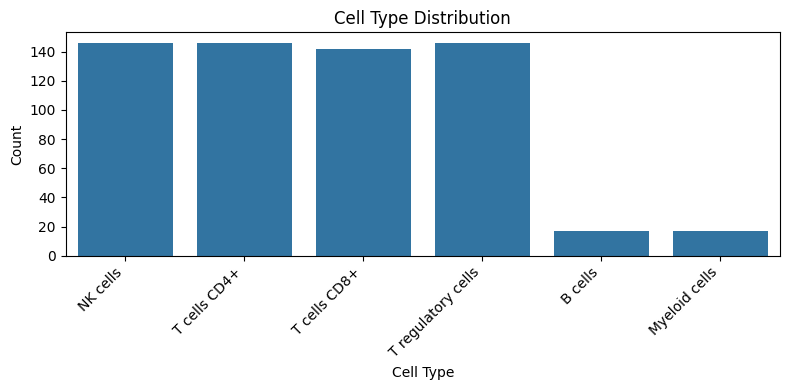

In [ ]:
plt.figure(figsize=(8,4))

sns.countplot(x='cell_type', data=df)

plt.title("Cell Type Distribution")
plt.xlabel("Cell Type")
plt.ylabel("Count")

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Adjust layout so labels are not cut
plt.tight_layout()

plt.show()

In [ ]:
X = df[['cell_type', 'sm_name', 'sm_lincs_id', 'SMILES']]

y = df[gene_columns]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (614, 4)
Output shape: (614, 18211)


# Compute Gene Variance and select top 3000

In [ ]:
gene_variance = y.var()
gene_variance.head()


,0
A1BG,2.672233
A1BG-AS1,1.412912
A2M,5.177489
A2M-AS1,4.770269
A2MP1,10.171037


In [ ]:

top_k = 3000

top_genes = gene_variance.sort_values(ascending=False).head(top_k).index

print("Selected genes:", len(top_genes))



Selected genes: 3000


In [ ]:
y_reduced = y[top_genes]

print("Reduced gene matrix shape:", y_reduced.shape)

Reduced gene matrix shape: (614, 3000)


In [ ]:
print("Final Input Shape:", X.shape)
print("Final Output Shape:", y_reduced.shape)

Final Input Shape: (614, 4)
Final Output Shape: (614, 3000)


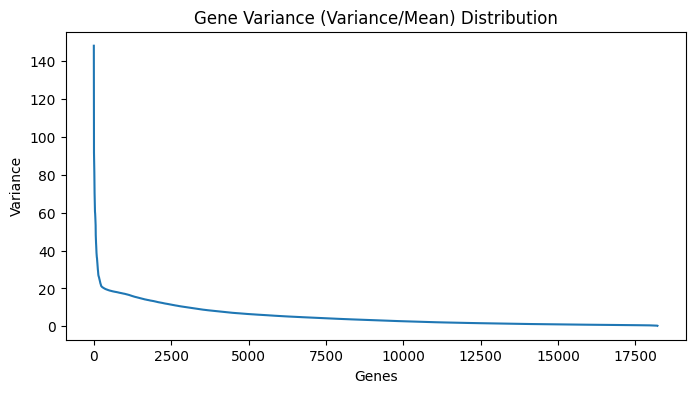

In [ ]:
import seaborn as sns

variances = gene_variance.sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.lineplot(x=range(len(variances)), y=variances.values)
plt.title("Gene Variance (Variance/Mean) Distribution")
plt.xlabel("Genes")
plt.ylabel("Variance")
plt.show()



# Feature Engineering

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch

In [ ]:
X_fe = X.copy()
y_fe = y_reduced.copy()

print("Feature shape:", X_fe.shape)
print("Label shape:", y_fe.shape)

Feature shape: (614, 4)
Label shape: (614, 3000)


# Encode Categorical Features

In [ ]:
categorical_cols = ['cell_type', 'sm_name', 'sm_lincs_id']

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X_fe[col] = le.fit_transform(X_fe[col])

    encoders[col] = le

    print(f"{col} classes:", len(le.classes_))

cell_type classes: 6
sm_name classes: 146
sm_lincs_id classes: 146


In [ ]:
X_fe.head()

,cell_type,sm_name,sm_lincs_id,SMILES
0,2,39,131,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1
1,3,39,131,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1
2,4,39,131,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1
3,5,39,131,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1
4,2,84,65,C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C...


# Handle SMILES (Character-Level Encoding)

In [ ]:
smiles_list = X_fe["SMILES"].astype(str).tolist()

# Build character vocabulary
chars = sorted(list(set("".join(smiles_list))))

char_to_idx = {c: i+1 for i, c in enumerate(chars)}
char_to_idx["PAD"] = 0

print("SMILES vocabulary size:", len(char_to_idx))

SMILES vocabulary size: 33


In [ ]:
max_smiles_len = 120

def encode_smiles(smiles):

    encoded = [char_to_idx.get(c,0) for c in smiles]

    if len(encoded) < max_smiles_len:
        encoded = encoded + [0]*(max_smiles_len - len(encoded))
    else:
        encoded = encoded[:max_smiles_len]

    return encoded

In [ ]:
smiles_encoded = np.array([encode_smiles(s) for s in smiles_list])

print("Encoded SMILES shape:", smiles_encoded.shape)

Encoded SMILES shape: (614, 120)


In [ ]:
X_fe = X_fe.drop(columns=["SMILES"])

print(X_fe.head())

   cell_type  sm_name  sm_lincs_id
0          2       39          131
1          3       39          131
2          4       39          131
3          5       39          131
4          2       84           65


In [ ]:
structured_features = X_fe.values

X_struct = X_fe[['cell_type','sm_name','sm_lincs_id']].values
X_smiles = smiles_encoded

print("Structured shape:", X_struct.shape)
print("SMILES shape:", X_smiles.shape)

Structured shape: (614, 3)
SMILES shape: (614, 120)


In [ ]:
y_array = y_fe.values

print("Label matrix shape:", y_array.shape)

Label matrix shape: (614, 3000)


# Train / Validation Split
We stratify using cell_type to keep distribution balanced.

In [ ]:
from sklearn.model_selection import train_test_split

X_struct_train, X_struct_val, \
X_smiles_train, X_smiles_val, \
smiles_train_raw, smiles_val_raw, \
y_train, y_val = train_test_split(
    X_struct,
    X_smiles,          # keep for GRU
    smiles_raw,        # GNN add this
    y_array,
    test_size=0.2,
    stratify=X_fe["cell_type"],
    random_state=42
)

print("Train shapes:")
print(X_struct_train.shape, X_smiles_train.shape, y_train.shape)

print("Validation shapes:")
print(X_struct_val.shape, X_smiles_val.shape, y_val.shape)

Train shapes:
(491, 3) (491, 120) (491, 3000)
Validation shapes:
(123, 3) (123, 120) (123, 3000)


In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_struct_train = scaler.fit_transform(X_struct_train)
X_struct_val = scaler.transform(X_struct_val)


# Convert to PyTorch Tensors

In [ ]:
import torch

# Structured features (float)
X_struct_train = torch.tensor(X_struct_train, dtype=torch.float32)
X_struct_val = torch.tensor(X_struct_val, dtype=torch.float32)

# SMILES sequences (long for embedding / GRU)
X_smiles_train = torch.tensor(X_smiles_train, dtype=torch.long)
X_smiles_val = torch.tensor(X_smiles_val, dtype=torch.long)

# Targets
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

print("Tensors ready")

Tensors ready


In [ ]:
import pickle

# Save encoders
with open("/content/drive/MyDrive/AML_PROJECT/encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

# Save SMILES vocab
with open("/content/drive/MyDrive/AML_PROJECT/smiles_vocab.pkl", "wb") as f:
    pickle.dump(char_to_idx, f)

# Save scaler
with open("/content/drive/MyDrive/AML_PROJECT/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save selected genes
with open("/content/drive/MyDrive/AML_PROJECT/top_genes.pkl", "wb") as f:
    pickle.dump(top_genes, f)

print("All preprocessing saved")

All preprocessing saved


# Normalize targets

In [ ]:
y_mean = y_train.mean(dim=0)
y_std = y_train.std(dim=0) + 1e-6

y_train = (y_train - y_mean) / y_std
y_val = (y_val - y_mean) / y_std

print("Targets normalized")

Targets normalized


# GRU MODEL

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class DualInputDataset(Dataset):
    def __init__(self, X_struct, X_smiles, y):
        self.X_struct = X_struct
        self.X_smiles = X_smiles
        self.y = y

    def __len__(self):
        return len(self.X_struct)

    def __getitem__(self, idx):
        return self.X_struct[idx], self.X_smiles[idx], self.y[idx]

In [ ]:
train_dataset = DualInputDataset(X_struct_train, X_smiles_train, y_train)
val_dataset = DualInputDataset(X_struct_val, X_smiles_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
class GRUModel(nn.Module):
    def __init__(self,
                 smiles_vocab_size,
                 smiles_embed_dim=128,
                 gru_hidden_dim=384,
                 structured_dim=3,
                 output_dim=3000):

        super(GRUModel, self).__init__()

        self.embedding = nn.Embedding(smiles_vocab_size, smiles_embed_dim, padding_idx=0)

        self.gru = nn.GRU(
            input_size=smiles_embed_dim,
            hidden_size=gru_hidden_dim,
            batch_first=True
        )

        self.struct_fc = nn.Sequential(
            nn.Linear(structured_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )

        self.fc = nn.Sequential(
            nn.Linear(gru_hidden_dim + 64, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.1),

            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.1),

            nn.Linear(512, output_dim)
        )

    def forward(self, x_struct, x_smiles):

        x_smiles = self.embedding(x_smiles)
        _, h = self.gru(x_smiles)
        h = h[-1]

        x_struct = self.struct_fc(x_struct)

        x = torch.cat([h, x_struct], dim=1)

        return self.fc(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GRUModel(
    smiles_vocab_size=len(char_to_idx) + 1,
    output_dim=y_train.shape[1]
).to(device)

print("Using device:", device)

Using device: cuda


In [ ]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
import time
def train_model(model, train_loader, val_loader, epochs=20):

    train_losses = []
    epoch_times = []
    val_losses = []

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss = 0

        for x_struct, x_smiles, y_batch in train_loader:

            x_struct = x_struct.to(device)
            x_smiles = x_smiles.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(x_struct, x_smiles)
            loss = criterion(outputs, y_batch)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item() * x_struct.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x_struct, x_smiles, y_batch in val_loader:

                x_struct = x_struct.to(device)
                x_smiles = x_smiles.to(device)
                y_batch = y_batch.to(device)

                outputs = model(x_struct, x_smiles)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item() * x_struct.size(0)

        val_loss /= len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        end_time = time.time()
        epoch_duration = end_time - start_time
        try:
            epoch_times.append(epoch_duration)
        except NameError:
            pass
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses, epoch_times


In [ ]:
train_losses, val_losses, epoch_times = train_model(model, train_loader, val_loader, epochs=30)


Epoch 1/30 | Train Loss: 0.6563 | Val Loss: 0.3542
Epoch 2/30 | Train Loss: 0.6116 | Val Loss: 0.3650
Epoch 3/30 | Train Loss: 0.5750 | Val Loss: 0.3711
Epoch 4/30 | Train Loss: 0.5433 | Val Loss: 0.3709
Epoch 5/30 | Train Loss: 0.5180 | Val Loss: 0.3720
Epoch 6/30 | Train Loss: 0.5005 | Val Loss: 0.3773
Epoch 7/30 | Train Loss: 0.4835 | Val Loss: 0.3813
Epoch 8/30 | Train Loss: 0.4770 | Val Loss: 0.3787
Epoch 9/30 | Train Loss: 0.4621 | Val Loss: 0.3755
Epoch 10/30 | Train Loss: 0.4575 | Val Loss: 0.3706
Epoch 11/30 | Train Loss: 0.4516 | Val Loss: 0.3662
Epoch 12/30 | Train Loss: 0.4441 | Val Loss: 0.3607
Epoch 13/30 | Train Loss: 0.4434 | Val Loss: 0.3542
Epoch 14/30 | Train Loss: 0.4351 | Val Loss: 0.3536
Epoch 15/30 | Train Loss: 0.4309 | Val Loss: 0.3485
Epoch 16/30 | Train Loss: 0.4249 | Val Loss: 0.3433
Epoch 17/30 | Train Loss: 0.4228 | Val Loss: 0.3430
Epoch 18/30 | Train Loss: 0.4228 | Val Loss: 0.3383
Epoch 19/30 | Train Loss: 0.4183 | Val Loss: 0.3343
Epoch 20/30 | Train L

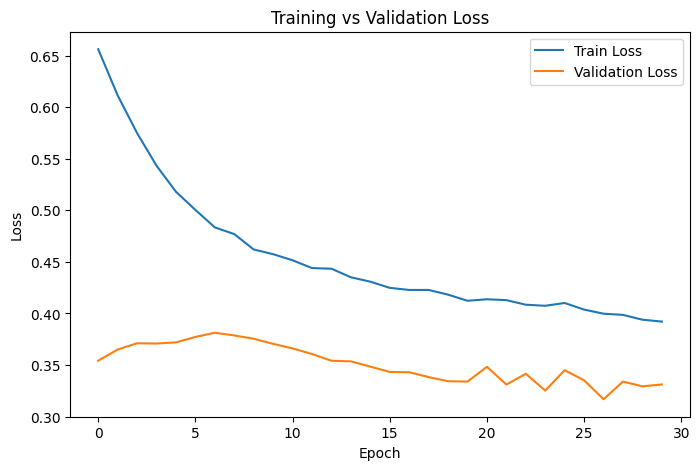

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
def sign_accuracy(y_pred, y_true):
    return (torch.sign(y_pred) == torch.sign(y_true)).float().mean()

model.eval()

with torch.no_grad():
    preds = model(X_struct_val.to(device), X_smiles_val.to(device))
    acc = sign_accuracy(preds, y_val.to(device))

print("Sign Accuracy:", acc.item())

Sign Accuracy: 0.7044363021850586


# GRU + ATTENTION MODEL




In [ ]:
import torch
import torch.nn as nn

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()

        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, gru_outputs):
        # gru_outputs: (batch, seq_len, hidden_dim)

        scores = self.attn(gru_outputs)  # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)

        # weighted sum
        context = torch.sum(weights * gru_outputs, dim=1)

        return context, weights

In [ ]:
class GRUAttentionModel(nn.Module):
    def __init__(self,
                 smiles_vocab_size,
                 smiles_embed_dim=64,
                 gru_hidden_dim=128,
                 structured_dim=3,
                 output_dim=3000):

        super(GRUAttentionModel, self).__init__()

        # SMILES embedding
        self.embedding = nn.Embedding(smiles_vocab_size, smiles_embed_dim, padding_idx=0)

        # GRU (return all outputs)
        self.gru = nn.GRU(
            input_size=smiles_embed_dim,
            hidden_size=gru_hidden_dim,
            batch_first=True
        )

        # Attention
        self.attention = Attention(gru_hidden_dim)

        # Structured branch
        self.struct_fc = nn.Sequential(
            nn.Linear(structured_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )

        # Final layers
        self.fc = nn.Sequential(
            nn.Linear(gru_hidden_dim + 64, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, output_dim)
        )

    def forward(self, x_struct, x_smiles):

        # SMILES branch
        x_smiles = self.embedding(x_smiles)  # (batch, seq_len, embed_dim)

        gru_out, _ = self.gru(x_smiles)      # (batch, seq_len, hidden_dim)

        context, attn_weights = self.attention(gru_out)

        # Structured branch
        x_struct = self.struct_fc(x_struct)

        # Combine
        x = torch.cat([context, x_struct], dim=1)

        # Output
        out = self.fc(x)

        return out, attn_weights

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GRUAttentionModel(
    smiles_vocab_size=len(char_to_idx)+1,
    output_dim=y_train.shape[1]
).to(device)

print("Attention model initialized on:", device)

Attention model initialized on: cuda


In [ ]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
import time
def train_model_attention(model, train_loader, val_loader, epochs=20):

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss = 0

        for x_struct, x_smiles, y_batch in train_loader:

            x_struct = x_struct.to(device)
            x_smiles = x_smiles.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs, _ = model(x_struct, x_smiles)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x_struct, x_smiles, y_batch in val_loader:

                x_struct = x_struct.to(device)
                x_smiles = x_smiles.to(device)
                y_batch = y_batch.to(device)

                outputs, _ = model(x_struct, x_smiles)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()

        end_time = time.time()
        epoch_duration = end_time - start_time
        try:
            epoch_times.append(epoch_duration)
        except NameError:
            pass
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


In [ ]:
train_model_attention(model, train_loader, val_loader, epochs=20)

Epoch 1/20 | Train Loss: 5.2362 | Val Loss: 0.6519
Epoch 2/20 | Train Loss: 4.4365 | Val Loss: 0.6043
Epoch 3/20 | Train Loss: 4.0225 | Val Loss: 0.5981
Epoch 4/20 | Train Loss: 3.7121 | Val Loss: 0.5712
Epoch 5/20 | Train Loss: 3.4411 | Val Loss: 0.5668
Epoch 6/20 | Train Loss: 3.3360 | Val Loss: 0.5607
Epoch 7/20 | Train Loss: 3.0968 | Val Loss: 0.6029
Epoch 8/20 | Train Loss: 3.0326 | Val Loss: 0.6163
Epoch 9/20 | Train Loss: 3.0371 | Val Loss: 0.6342
Epoch 10/20 | Train Loss: 3.0990 | Val Loss: 0.6351
Epoch 11/20 | Train Loss: 3.0309 | Val Loss: 0.6113
Epoch 12/20 | Train Loss: 2.8835 | Val Loss: 0.5838
Epoch 13/20 | Train Loss: 3.0777 | Val Loss: 0.6531
Epoch 14/20 | Train Loss: 2.9219 | Val Loss: 0.6563
Epoch 15/20 | Train Loss: 2.8179 | Val Loss: 0.6282
Epoch 16/20 | Train Loss: 2.7138 | Val Loss: 0.6073
Epoch 17/20 | Train Loss: 2.8777 | Val Loss: 0.5706
Epoch 18/20 | Train Loss: 2.8294 | Val Loss: 0.6119
Epoch 19/20 | Train Loss: 2.7677 | Val Loss: 0.6700
Epoch 20/20 | Train L

In [ ]:
model.eval()

with torch.no_grad():
    preds, attn_weights = model(X_struct_val.to(device), X_smiles_val.to(device))

    acc = (torch.sign(preds) == torch.sign(y_val.to(device))).float().mean()

print("Sign Accuracy:", acc.item())

Sign Accuracy: 0.8053387403488159


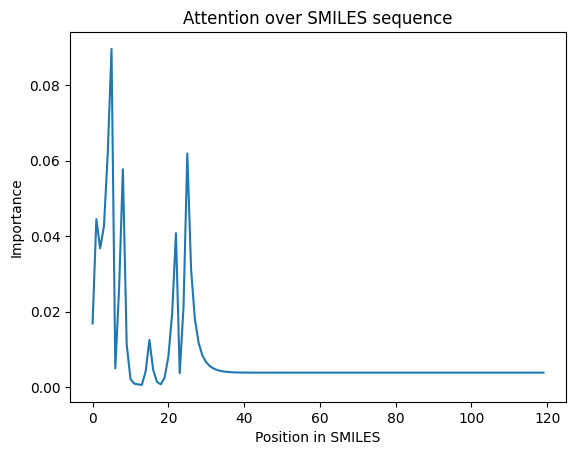

In [ ]:
import matplotlib.pyplot as plt

# Pick one sample
sample_weights = attn_weights[0].cpu().numpy()

plt.plot(sample_weights)
plt.title("Attention over SMILES sequence")
plt.xlabel("Position in SMILES")
plt.ylabel("Importance")
plt.show()

In [ ]:
!pip install torch-geometric
!pip install rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 26.1 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset

import numpy as np

from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

In [ ]:
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    # Node features (atoms)
    node_features = []
    for atom in mol.GetAtoms():
        node_features.append([
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            atom.GetHybridization(),
            atom.GetIsAromatic()
        ])

    x = torch.tensor(node_features, dtype=torch.float)

    # Edge index
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    return x, edge_index

In [ ]:
class GNNDataset(Dataset):
    def __init__(self, smiles_list, struct_data, targets):
        self.smiles = smiles_list
        self.struct = struct_data
        self.targets = targets

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smiles = self.smiles[idx]
        x, edge_index = smiles_to_graph(smiles)

        data = Data(x=x, edge_index=edge_index)

        data.struct = self.struct[idx].clone().detach().float()
        data.y = self.targets[idx].clone().detach().float()

        return data

In [ ]:
train_dataset = GNNDataset(smiles_train_raw,X_struct_train, y_train)
val_dataset   = GNNDataset(smiles_val_raw, X_struct_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
class GNNModel(nn.Module):
    def __init__(self, struct_dim=3, output_dim=3000):
        super(GNNModel, self).__init__()

        # Graph layers
        self.conv1 = GCNConv(5, 64)
        self.conv2 = GCNConv(64, 128)

        # Structured branch
        self.struct_fc = nn.Sequential(
            nn.Linear(struct_dim, 64),
            nn.ReLU()
        )

        # Final layers
        self.fc = nn.Sequential(
            nn.Linear(128 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, output_dim)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # GNN
        x = self.conv1(x, edge_index)
        x = torch.relu(x)

        x = self.conv2(x, edge_index)
        x = torch.relu(x)

        # Pool graph → vector
        x = global_mean_pool(x, batch)

        # Get batch size
        batch_size = data.num_graphs

        # Reshape struct properly
        struct = data.struct.view(batch_size, -1)

        # Pass through FC
        struct = self.struct_fc(struct)

        # Combine
        x = torch.cat([x, struct], dim=1)

        return self.fc(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GNNModel(output_dim=y_train.shape[1]).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
import time
def train_model(model, train_loader, val_loader, epochs=20):

    train_losses = []
    epoch_times = []
    val_losses = []

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss = 0

        for data in train_loader:
            data = data.to(device)

            optimizer.zero_grad()

            output = model(data)
            output = model(data)

            y = data.y.view(data.num_graphs, -1)

            loss = criterion(output, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * data.num_graphs

        train_loss /= len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)

                output = model(data)

                y = data.y.view(data.num_graphs, -1)
                loss = criterion(output, y)

                val_loss += loss.item() * data.num_graphs

        val_loss /= len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        end_time = time.time()
        epoch_duration = end_time - start_time
        try:
            epoch_times.append(epoch_duration)
        except NameError:
            pass
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses, epoch_times


In [ ]:
train_losses, val_losses, epoch_times = train_model(model, train_loader, val_loader, epochs=30)


Epoch 1/30 | Train Loss: 0.3531 | Val Loss: 0.2765
Epoch 2/30 | Train Loss: 0.3344 | Val Loss: 0.2755
Epoch 3/30 | Train Loss: 0.3323 | Val Loss: 0.2716
Epoch 4/30 | Train Loss: 0.3289 | Val Loss: 0.2698
Epoch 5/30 | Train Loss: 0.3279 | Val Loss: 0.2696
Epoch 6/30 | Train Loss: 0.3273 | Val Loss: 0.2705
Epoch 7/30 | Train Loss: 0.3273 | Val Loss: 0.2709
Epoch 8/30 | Train Loss: 0.3263 | Val Loss: 0.2676
Epoch 9/30 | Train Loss: 0.3253 | Val Loss: 0.2670
Epoch 10/30 | Train Loss: 0.3247 | Val Loss: 0.2692
Epoch 11/30 | Train Loss: 0.3245 | Val Loss: 0.2686
Epoch 12/30 | Train Loss: 0.3237 | Val Loss: 0.2694
Epoch 13/30 | Train Loss: 0.3244 | Val Loss: 0.2674
Epoch 14/30 | Train Loss: 0.3228 | Val Loss: 0.2709
Epoch 15/30 | Train Loss: 0.3228 | Val Loss: 0.2669
Epoch 16/30 | Train Loss: 0.3215 | Val Loss: 0.2731
Epoch 17/30 | Train Loss: 0.3233 | Val Loss: 0.2679
Epoch 18/30 | Train Loss: 0.3214 | Val Loss: 0.2686
Epoch 19/30 | Train Loss: 0.3231 | Val Loss: 0.2665
Epoch 20/30 | Train L

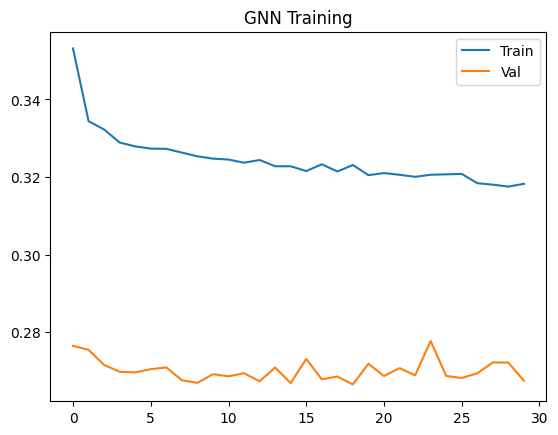

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.legend()
plt.title("GNN Training")
plt.show()

In [ ]:
def sign_accuracy(y_pred, y_true):
    return (torch.sign(y_pred) == torch.sign(y_true)).float().mean()

model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for data in val_loader:
        data = data.to(device)

        preds = model(data)

        # ✅ FIX: reshape target
        y = data.y.view(data.num_graphs, -1)

        all_preds.append(preds)
        all_true.append(y)

# Concatenate all batches
preds = torch.cat(all_preds, dim=0)
true  = torch.cat(all_true, dim=0)

# Compute sign accuracy
acc = sign_accuracy(preds, true)

print("Sign Accuracy:", acc.item())

Sign Accuracy: 0.8163577318191528


# GAT (Graph Attention Network)

In [ ]:
import torch
import torch.nn as nn
import numpy as np

from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool

In [ ]:
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    node_features = []
    for atom in mol.GetAtoms():
        node_features.append([
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            int(atom.GetHybridization()),
            int(atom.GetIsAromatic()),
            atom.GetTotalNumHs(),
            atom.GetValence(Chem.ValenceType.IMPLICIT)
        ])

    x = torch.tensor(node_features, dtype=torch.float)

    # Normalize node features
    x = (x - x.mean(dim=0)) / (x.std(dim=0) + 1e-5)

    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    return x, edge_index

In [ ]:
class GNNDataset(torch.utils.data.Dataset):
    def __init__(self, smiles_list, struct_data, targets):
        self.smiles = smiles_list
        self.struct = struct_data
        self.targets = targets

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        x, edge_index = smiles_to_graph(self.smiles[idx])

        data = Data(x=x, edge_index=edge_index)

        data.struct = self.struct[idx].clone().detach().float()
        data.y = self.targets[idx].clone().detach().float()

        return data

In [ ]:
train_dataset = GNNDataset(smiles_train_raw, X_struct_train, y_train)
val_dataset   = GNNDataset(smiles_val_raw, X_struct_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool

class GATModel(nn.Module):
    def __init__(self, struct_dim=3, output_dim=3000):
        super(GATModel, self).__init__()

        # GAT layers
        self.conv1 = GATConv(7, 64, heads=4)        # -> 64*4 = 256
        self.bn1 = nn.BatchNorm1d(256)

        self.conv2 = GATConv(256, 128, heads=2)     # -> 128*2 = 256
        self.bn2 = nn.BatchNorm1d(256)

        # Structured branch
        self.struct_fc = nn.Sequential(
            nn.Linear(struct_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )

        # Final layers (FIXED DIMENSIONS)
        self.fc = nn.Sequential(
            nn.Linear(256*2 + 64, 256),  # (mean+max)=512 + struct=64 → 576
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, output_dim)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # ---- GAT Block 1 ----
        x1 = self.conv1(x, edge_index)
        x1 = self.bn1(x1)
        x1 = F.relu(x1)

        # ---- GAT Block 2 (Residual) ----
        x2 = self.conv2(x1, edge_index)
        x2 = self.bn2(x2)
        x2 = F.relu(x2)

        x = x1 + x2   # 🔥 residual connection

        # ---- Pooling ----
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)  # 512

        # ---- Structured branch ----
        struct = data.struct.view(data.num_graphs, -1)
        struct = self.struct_fc(struct)

        # ---- Combine ----
        x = torch.cat([x, struct], dim=1)  # 512 + 64 = 576

        return self.fc(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GATModel(
    struct_dim=X_struct_train.shape[1],
    output_dim=y_train.shape[1]
).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

In [ ]:
import time
def train_model(model, train_loader, val_loader, epochs=20):

    train_losses = []
    epoch_times = []
    val_losses = []

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss = 0

        for data in train_loader:
            data = data.to(device)

            optimizer.zero_grad()

            output = model(data)
            y = data.y.view(data.num_graphs, -1)

            loss = criterion(output, y)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item() * data.num_graphs

        train_loss /= len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)

                output = model(data)
                y = data.y.view(data.num_graphs, -1)

                loss = criterion(output, y)
                val_loss += loss.item() * data.num_graphs

        val_loss /= len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        end_time = time.time()
        epoch_duration = end_time - start_time
        try:
            epoch_times.append(epoch_duration)
        except NameError:
            pass
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses, epoch_times


In [ ]:
train_losses, val_losses, epoch_times = train_model(model, train_loader, val_loader, epochs=25)


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 1/25 | Train Loss: 0.4067 | Val Loss: 0.3319
Epoch 2/25 | Train Loss: 0.3615 | Val Loss: 0.3038
Epoch 3/25 | Train Loss: 0.3447 | Val Loss: 0.2860
Epoch 4/25 | Train Loss: 0.3392 | Val Loss: 0.2820
Epoch 5/25 | Train Loss: 0.3371 | Val Loss: 0.2715
Epoch 6/25 | Train Loss: 0.3343 | Val Loss: 0.2701
Epoch 7/25 | Train Loss: 0.3309 | Val Loss: 0.2694
Epoch 8/25 | Train Loss: 0.3292 | Val Loss: 0.2679
Epoch 9/25 | Train Loss: 0.3283 | Val Loss: 0.2723
Epoch 10/25 | Train Loss: 0.3256 | Val Loss: 0.2728
Epoch 11/25 | Train Loss: 0.3239 | Val Loss: 0.2683
Epoch 12/25 | Train Loss: 0.3246 | Val Loss: 0.2677
Epoch 13/25 | Train Loss: 0.3244 | Val Loss: 0.2654
Epoch 14/25 | Train Loss: 0.3222 | Val Loss: 0.2708
Epoch 15/25 | Train Loss: 0.3212 | Val Loss: 0.2693
Epoch 16/25 | Train Loss: 0.3207 | Val Loss: 0.2677
Epoch 17/25 | Train Loss: 0.3217 | Val Loss: 0.2695
Epoch 18/25 | Train Loss: 0.3216 | Val Loss: 0.2681
Epoch 19/25 | Train Loss: 0.3191 | Val Loss: 0.2676
Epoch 20/25 | Train L

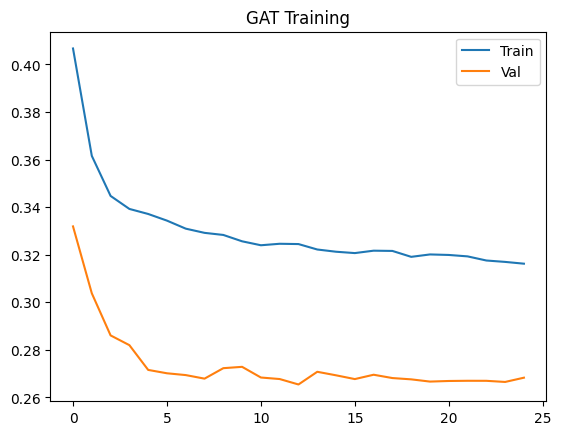

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.legend()
plt.title("GAT Training")
plt.show()

In [ ]:
def sign_accuracy(y_pred, y_true):
    return (torch.sign(y_pred) == torch.sign(y_true)).float().mean()

model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for data in val_loader:
        data = data.to(device)

        preds = model(data)
        y = data.y.view(data.num_graphs, -1)

        all_preds.append(preds)
        all_true.append(y)

preds = torch.cat(all_preds, dim=0)
true  = torch.cat(all_true, dim=0)

acc = sign_accuracy(preds, true)

print("Sign Accuracy:", acc.item())

Sign Accuracy: 0.8205474019050598


In [ ]:
import torch

torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/AML_PROJECT/GAT_best_model.pth"
)

print("GAT model saved successfully!")

GAT model saved successfully!


# Benchmark: 3k vs 18k Genes
Training GRU model on 3000 selected genes vs all 18211 genes for a quick comparison of training time and validation accuracy.

In [ ]:
import time
import torch

# --- Prepare 18k Data ---
X_struct_train_18k, X_struct_val_18k, \
X_smiles_train_18k, X_smiles_val_18k, \
y_train_18k, y_val_18k = train_test_split(
    X_struct,
    X_smiles,
    df[gene_columns],
    test_size=0.2,
    stratify=X_fe["cell_type"],
    random_state=42
)

# Normalize structured features
X_struct_train_18k = scaler.fit_transform(X_struct_train_18k)
X_struct_val_18k = scaler.transform(X_struct_val_18k)

# Convert to Tensors
X_struct_train_18k = torch.tensor(X_struct_train_18k, dtype=torch.float32)
X_struct_val_18k = torch.tensor(X_struct_val_18k, dtype=torch.float32)
X_smiles_train_18k = torch.tensor(X_smiles_train_18k, dtype=torch.long)
X_smiles_val_18k = torch.tensor(X_smiles_val_18k, dtype=torch.long)
y_train_18k = torch.tensor(y_train_18k.values, dtype=torch.float32)
y_val_18k = torch.tensor(y_val_18k.values, dtype=torch.float32)

# Normalize 18k targets
y_mean_18k = y_train_18k.mean(dim=0)
y_std_18k = y_train_18k.std(dim=0) + 1e-6
y_train_18k = (y_train_18k - y_mean_18k) / y_std_18k
y_val_18k = (y_val_18k - y_mean_18k) / y_std_18k

# Loaders
train_loader_18k = DataLoader(DualInputDataset(X_struct_train_18k, X_smiles_train_18k, y_train_18k), batch_size=64, shuffle=True)
val_loader_18k = DataLoader(DualInputDataset(X_struct_val_18k, X_smiles_val_18k, y_val_18k), batch_size=64, shuffle=False)



In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time

# Re-initialize train_loader and val_loader for DualInputDataset
class DualInputDataset(Dataset):
    def __init__(self, X_struct, X_smiles, y):
        self.X_struct = X_struct
        self.X_smiles = X_smiles
        self.y = y

    def __len__(self):
        return len(self.X_struct)

    def __getitem__(self, idx):
        return self.X_struct[idx], self.X_smiles[idx], self.y[idx]

train_dataset = DualInputDataset(X_struct_train, X_smiles_train, y_train)
val_dataset = DualInputDataset(X_struct_val, X_smiles_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# --- Train 3k Baseline (for benchmark) ---
model_3k = GRUModel(smiles_vocab_size=len(char_to_idx) + 1, output_dim=3000).to(device)
optimizer_3k = torch.optim.Adam(model_3k.parameters(), lr=1e-4)
criterion = nn.L1Loss()

def train_bench(model, train_loader, val_loader, optimizer, epochs=30):
    epoch_times = []
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        for x_struct, x_smiles, y_batch in train_loader:
            x_struct, x_smiles, y_batch = x_struct.to(device), x_smiles.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x_struct, x_smiles), y_batch)
            loss.backward()
            optimizer.step()
        epoch_times.append(time.time() - start_time)

    model.eval()
    with torch.no_grad():
        preds, true = [], []
        for x_struct, x_smiles, y_batch in val_loader:
            preds.append(model(x_struct.to(device), x_smiles.to(device)))
            true.append(y_batch.to(device))
        preds = torch.cat(preds, dim=0)
        true = torch.cat(true, dim=0)
        acc = (torch.sign(preds) == torch.sign(true)).float().mean().item()
    return epoch_times, acc

print('Training 3k Model...')
times_3k, acc_3k = train_bench(model_3k, train_loader, val_loader, optimizer_3k, epochs=30)

print('Training 18k Model...')
model_18k = GRUModel(smiles_vocab_size=len(char_to_idx) + 1, output_dim=18211).to(device)
optimizer_18k = torch.optim.Adam(model_18k.parameters(), lr=1e-4)
times_18k, acc_18k = train_bench(model_18k, train_loader_18k, val_loader_18k, optimizer_18k, epochs=30)

Training 3k Model...
Training 18k Model...


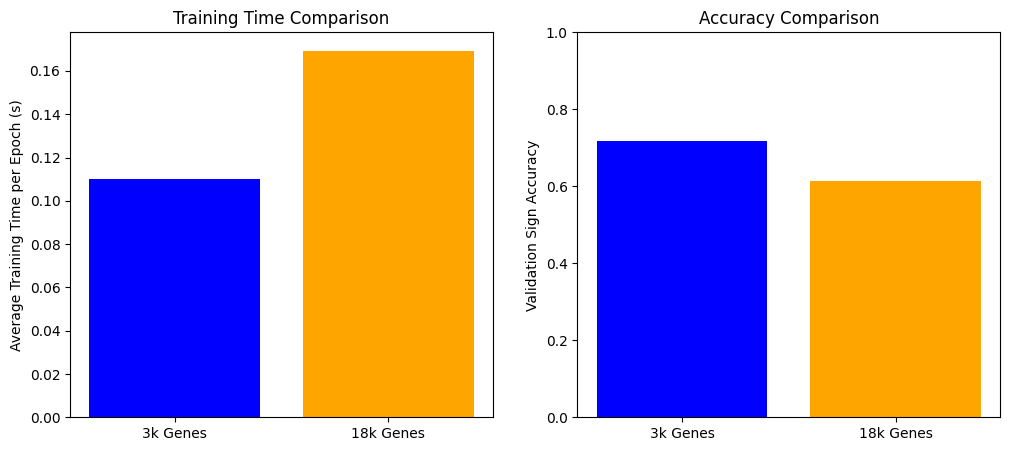

3k Genes -> Avg Time/Epoch: 0.11s | Sign Accuracy: 0.7178
18k Genes -> Avg Time/Epoch: 0.17s | Sign Accuracy: 0.6150


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

labels = ['3k Genes', '18k Genes']
avg_times = [np.mean(times_3k), np.mean(times_18k)]
accs = [acc_3k, acc_18k]

ax1.bar(labels, avg_times, color=['blue', 'orange'])
ax1.set_ylabel('Average Training Time per Epoch (s)')
ax1.set_title('Training Time Comparison')

ax2.bar(labels, accs, color=['blue', 'orange'])
ax2.set_ylabel('Validation Sign Accuracy')
ax2.set_title('Accuracy Comparison')
ax2.set_ylim([0, 1])

plt.show()

print(f"3k Genes -> Avg Time/Epoch: {avg_times[0]:.2f}s | Sign Accuracy: {accs[0]:.4f}")
print(f"18k Genes -> Avg Time/Epoch: {avg_times[1]:.2f}s | Sign Accuracy: {accs[1]:.4f}")
